In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define the autoencoder model with 1D Convolutional layers
input_dim = X_scaled.shape[1]
latent_dim = 64

input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

autoencoder = Model(input_layer, decoder_layer5)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the data
autoencoder.fit(X_scaled, X_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])

Epoch 1/100
986/986 [==============================] - 49s 45ms/step - loss: 0.0055 - val_loss: 2.0832e-04
Epoch 2/100
986/986 [==============================] - 46s 46ms/step - loss: 1.4219e-04 - val_loss: 9.0878e-05
Epoch 3/100
986/986 [==============================] - 47s 48ms/step - loss: 7.2947e-05 - val_loss: 6.2800e-05
Epoch 4/100
986/986 [==============================] - 47s 47ms/step - loss: 5.5075e-05 - val_loss: 4.4773e-05
Epoch 5/100
986/986 [==============================] - 46s 46ms/step - loss: 4.6907e-05 - val_loss: 3.8321e-05
Epoch 6/100
986/986 [==============================] - 47s 48ms/step - loss: 3.8920e-05 - val_loss: 3.4272e-05
Epoch 7/100
986/986 [==============================] - 47s 48ms/step - loss: 3.6034e-05 - val_loss: 3.0671e-05
Epoch 8/100
986/986 [==============================] - 44s 45ms/step - loss: 3.1632e-05 - val_loss: 2.8818e-05
Epoch 9/100
986/986 [==============================] - 44s 45ms/step - loss: 2.9793e-05 - val_loss: 2.6007e-05
Epoch

1095/1095 [==============================] - 16s 14ms/step
Model saved at: trained_1D_autoencoder_model.h5
Threshold saved at: trained_1D_threshold.npy


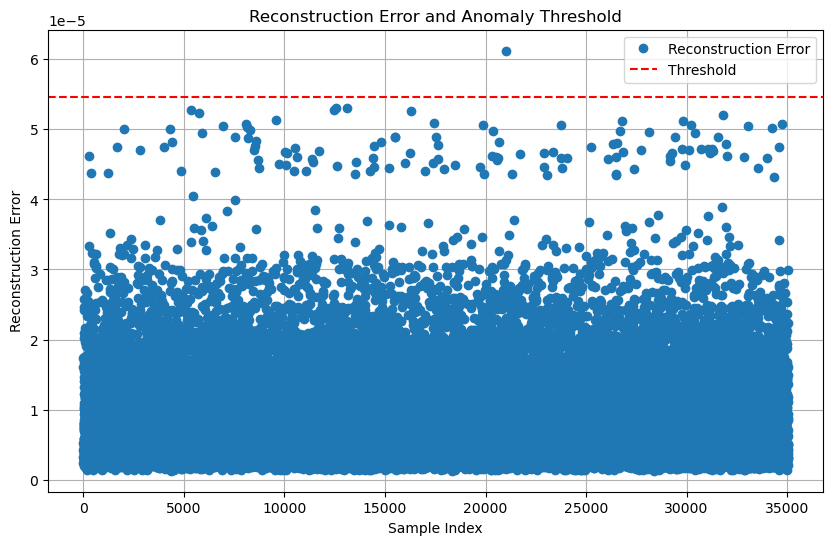

In [9]:
# Calculate reconstruction error
train_predictions = autoencoder.predict(X_scaled)
# reconstruction_error = np.mean(np.square(X_scaled - train_predictions), axis=1)
#################################################################################
# Calculate reconstruction error
reshaped_train_predictions = train_predictions.reshape(X_scaled.shape)  # Reshape to match original input shape
reconstruction_error = np.mean(np.square(X_scaled - reshaped_train_predictions), axis=1)
################################################################################

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (16 * mad)

# Print and save the trained autoencoder model
model_path = "trained_1D_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_1D_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold')
plt.legend()
plt.grid()
plt.show()


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the 1D Convolutional Autoencoder model
# input_dim = X_train_scaled.shape[1]
# latent_dim = 64

# input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
# encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
# encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
# encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
# encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

# decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
# decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
# decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
# decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
# decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

# autoencoder = Model(input_layer, decoder_layer5)
# autoencoder.compile(optimizer='adam', loss='mse')

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
# anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\AppData\Local\Temp\ipykernel_14848\2022420320.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_14848\2022420320.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


9/9 [==============================] - 0s 17ms/step
Threshold saved at: 5.4589054708696715e-05
Anomalous Data Indices:
[  0   2   6  10  27  28  33  39  43  44  45  47  50  55  68  74  77  91
  97  98 107 112 116 123 128 132 137 144 150 152 158 190 191 194 195 199
 212 214 237 249 250 277 282 286 287]


Accuracy: 0.65625
Precision: 0.9777777777777777
Recall: 0.30985915492957744
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.6901408450704225
F1 Score: 0.47058823529411764
ROC AUC: 0.7703550067528459


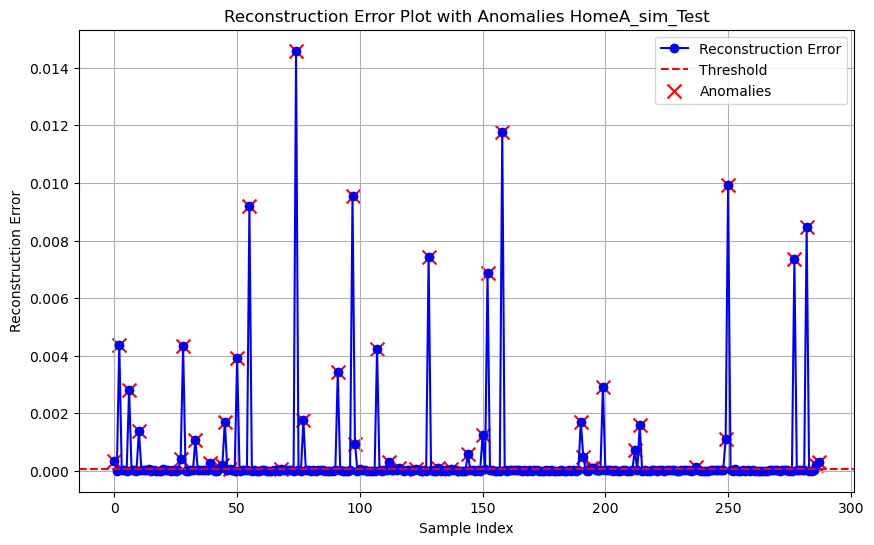

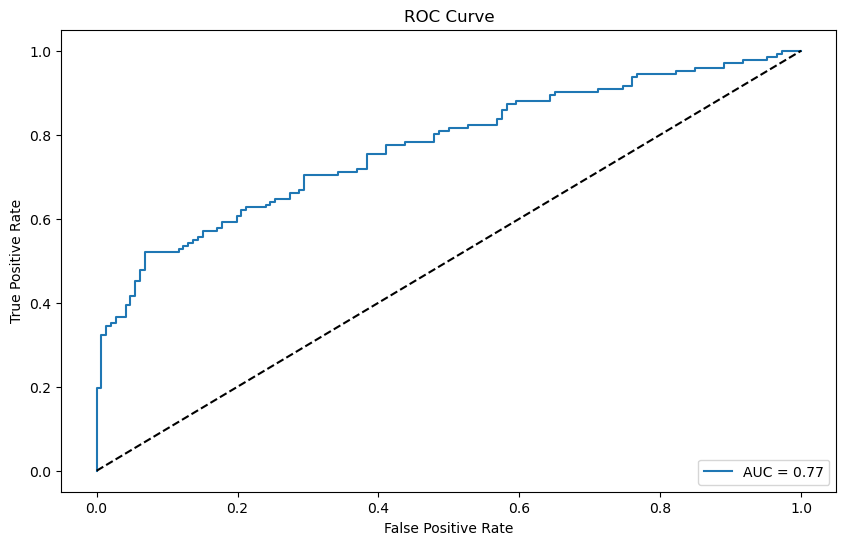

In [11]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the 1D Convolutional Autoencoder model
# input_dim = X_train_scaled.shape[1]
# latent_dim = 64

# input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
# encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
# encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
# encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
# encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

# decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
# decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
# decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
# decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
# decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

# autoencoder = Model(input_layer, decoder_layer5)
# autoencoder.compile(optimizer='adam', loss='mse')

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
# anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\AppData\Local\Temp\ipykernel_14848\2755573688.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_14848\2755573688.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


548/548 [==============================] - 8s 14ms/step
Threshold saved at: 5.4589054708696715e-05
Anomalous Data Indices:
[  101   126   133   134   154   168   170   209   224   252   263   274
   279   288   325   346   356   378   420   427   441   483   490   496
   517   570   592   605   624   642   644   658   686   723   744   780
   783   825   877   878   882   934   944   966   975   985   988  1036
  1044  1057  1071  1109  1146  1167  1177  1182  1188  1201  1202  1211
  1212  1236  1260  1274  1287  1312  1317  1323  1324  1329  1344  1354
  1377  1384  1386  1391  1401  1446  1455  1461  1499  1503  1507  1523
  1549  1598  1599  1617  1656  1657  1663  1710  1711  1724  1763  1770
  1792  1830  1849  1868  1888  1920  1925  1942  1964  2004  2005  2013
  2016  2055  2108  2113  2117  2168  2170  2181  2200  2201  2214  2217
  2246  2259  2333  2340  2349  2367  2394  2416  2422  2483  2537  2570
  2580  2617  2624  2630  2651  2672  2689  2720  2734  2749  2754  2769
 

Accuracy: 0.5358447488584475
Precision: 0.8458149779735683
Recall: 0.08767123287671233
TNR: 0.9840182648401826
FPR: 0.01598173515981735
FNR: 0.9123287671232877
F1 Score: 0.15887463798096813
ROC AUC: 0.7176662288109089


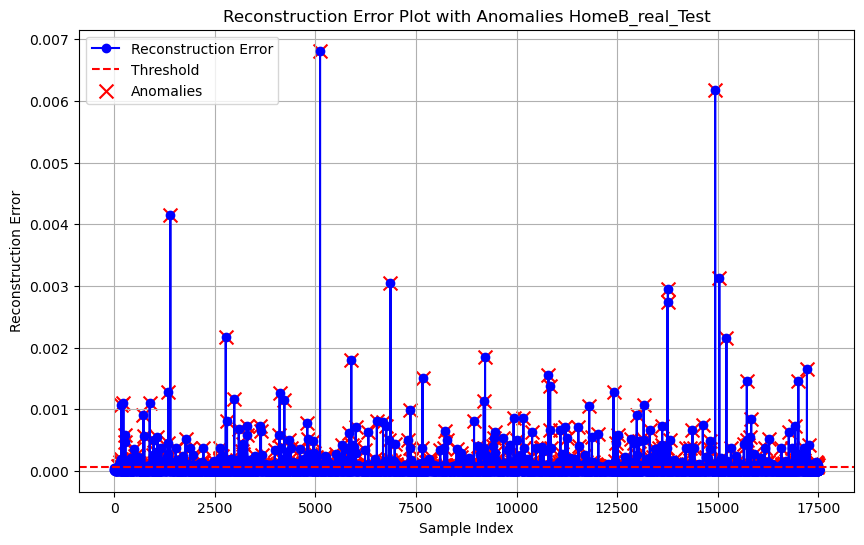

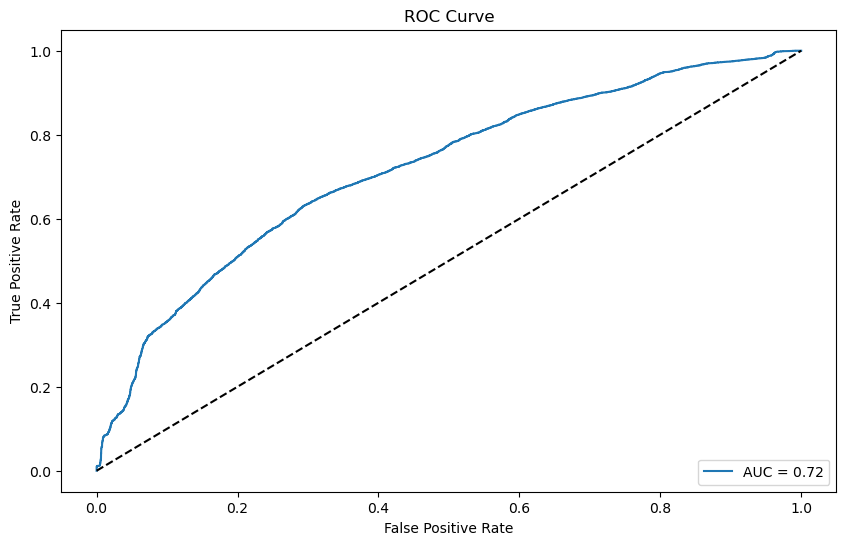

In [15]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define the 1D Convolutional Autoencoder model with downsampling
input_dim = X_scaled.shape[1]
encoding_dim = 64

input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

autoencoder = Model(input_layer, decoder_layer5)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=64,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])


Epoch 1/50
493/493 [==============================] - 44s 79ms/step - loss: 0.0109 - val_loss: 5.6148e-04
Epoch 2/50
493/493 [==============================] - 38s 77ms/step - loss: 4.1496e-04 - val_loss: 2.5308e-04
Epoch 3/50
493/493 [==============================] - 40s 82ms/step - loss: 1.8567e-04 - val_loss: 1.3973e-04
Epoch 4/50
493/493 [==============================] - 38s 78ms/step - loss: 1.2293e-04 - val_loss: 1.1267e-04
Epoch 5/50
493/493 [==============================] - 42s 84ms/step - loss: 8.9974e-05 - val_loss: 7.7446e-05
Epoch 6/50
493/493 [==============================] - 42s 86ms/step - loss: 7.4901e-05 - val_loss: 7.4209e-05
Epoch 7/50
493/493 [==============================] - 41s 83ms/step - loss: 6.6328e-05 - val_loss: 6.1754e-05
Epoch 8/50
493/493 [==============================] - 39s 79ms/step - loss: 6.1877e-05 - val_loss: 5.4965e-05
Epoch 9/50
493/493 [==============================] - 39s 79ms/step - loss: 5.4072e-05 - val_loss: 4.8618e-05
Epoch 10/50
49

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1380, 1)]         0         
                                                                 
 conv1d (Conv1D)             (None, 1380, 32)          128       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 690, 32)          0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 690, 64)           6208      
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 345, 64)          0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 345, 64)           12352 

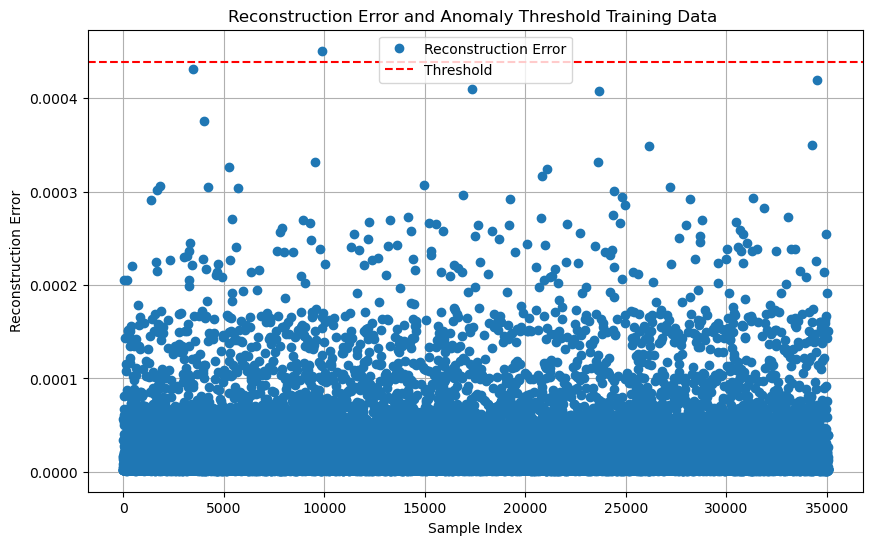

In [8]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for training data
train_predictions = autoencoder.predict(X_scaled)
# reconstruction_error = np.mean(np.square(X_scaled - train_predictions), axis=1)

reshaped_train_predictions = train_predictions.reshape(X_scaled.shape)  # Reshape to match original input shape
reconstruction_error = np.mean(np.square(X_scaled - reshaped_train_predictions), axis=1)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (270 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_1D-autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_1D-threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Training Data ')
plt.legend()
plt.grid()
plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

C:\Users\olufe\AppData\Local\Temp\ipykernel_22324\3828226478.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_22324\3828226478.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


9/9 [==============================] - 0s 15ms/step
Threshold saved at: 5.4589054708696715e-05
Anomalous Data Indices:
[  1   9  14  15  20  22  28  29  32  35  37  48  66  69  70  71  73  75
  77  90  98  99 102 105 107 111 116 127 133 134 137 138 150 153 157 160
 163 173 176 178 180 186 187 189 190 193 194 196 197 206 209 210 212 216
 220 223 225 227 234 236 237 238 240 241 246 247 249 251 255 258 259 268
 269 272 273 276 277 278]


Accuracy: 0.6021505376344086
Precision: 0.6410256410256411
Recall: 0.37593984962406013
TNR: 0.8082191780821918
FPR: 0.1917808219178082
FNR: 0.6240601503759399
F1 Score: 0.47393364928909953
ROC AUC: 0.6494489648779482


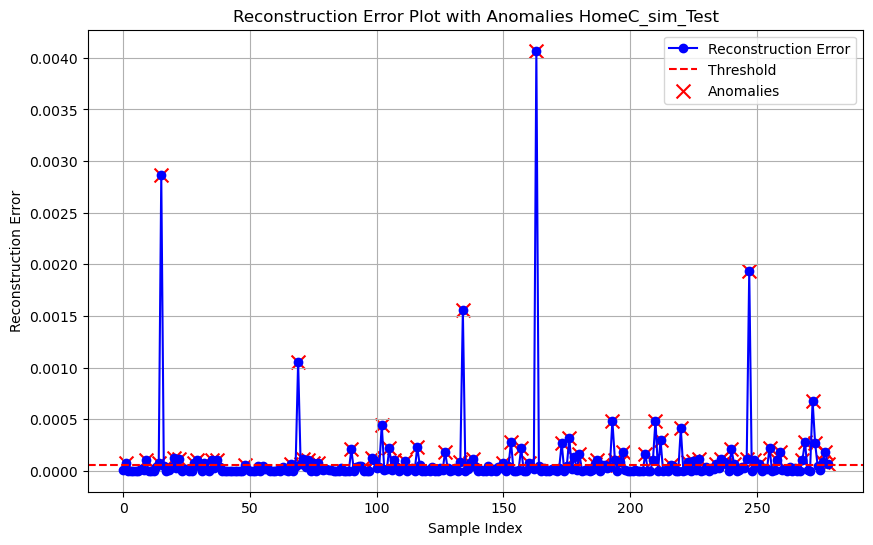

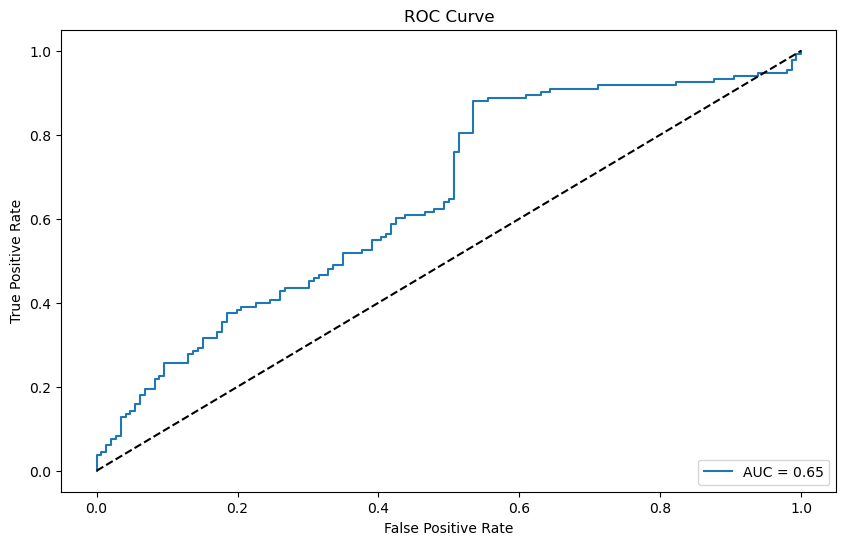

In [10]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeC_sim_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

C:\Users\olufe\AppData\Local\Temp\ipykernel_22324\933712370.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_22324\933712370.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


548/548 [==============================] - 8s 15ms/step
Threshold saved at: 5.4589054708696715e-05
Anomalous Data Indices:
[    3     8    18 ... 17512 17513 17517]


Accuracy: 0.510958904109589
Precision: 0.5268456375838926
Recall: 0.21506849315068494
TNR: 0.8068493150684931
FPR: 0.19315068493150686
FNR: 0.7849315068493151
F1 Score: 0.3054474708171206
ROC AUC: 0.549448197493797


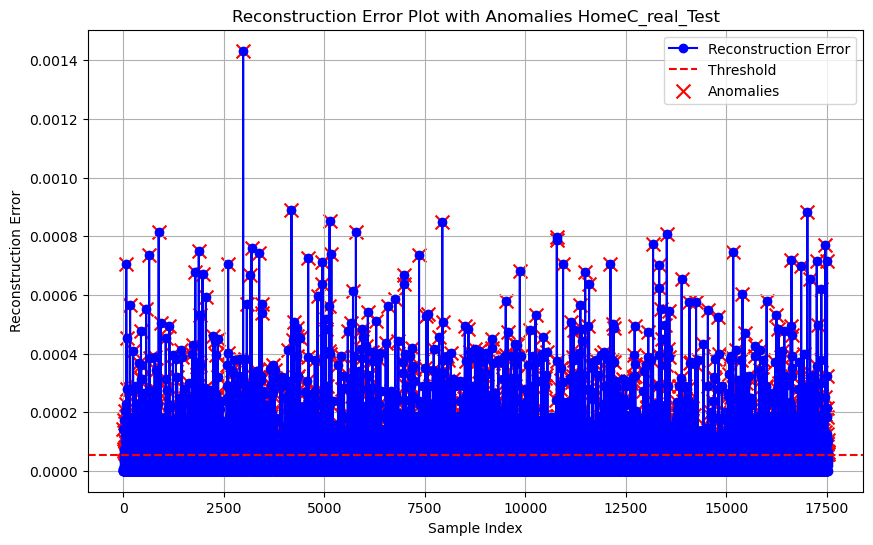

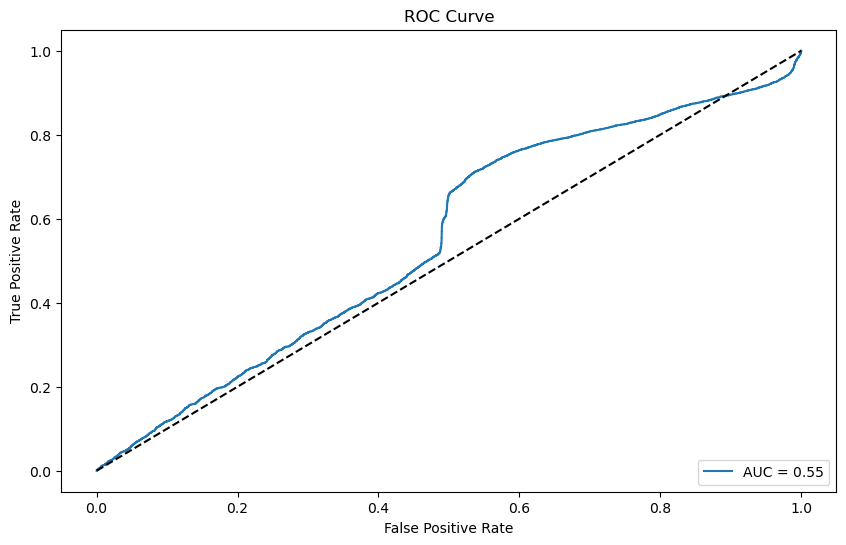

In [12]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeC_real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
